In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/smartcart_customers.csv" \
"")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## Handle The Missing values


In [6]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df["Income"]

0       58138.0
1       46344.0
2       71613.0
3       26646.0
4       58293.0
         ...   
2235    61223.0
2236    64014.0
2237    56981.0
2238    69245.0
2239    52869.0
Name: Income, Length: 2240, dtype: float64

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

# Feature Engineering

In [9]:
df["Age"]=2026-df["Year_Birth"]

In [10]:
df["Age"]

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2240, dtype: int64

In [11]:
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date- df["Dt_Customer"]).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='str')

In [14]:
df["Total_Spending"]=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [16]:
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [18]:
#Education

df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
df["Education"].values

<StringArray>
['Graduation', 'Graduation', 'Graduation', 'Graduation',        'PhD',
     'Master', 'Graduation',        'PhD',        'PhD',        'PhD',
 ...
 'Graduation',     'Master', 'Graduation', 'Graduation', 'Graduation',
 'Graduation',        'PhD', 'Graduation',     'Master',        'PhD']
Length: 2240, dtype: str

In [45]:
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})

In [46]:
df["Education"] 

0           Graduate
1           Graduate
2           Graduate
3           Graduate
4       Postgraduate
            ...     
2235        Graduate
2236    Postgraduate
2237        Graduate
2238    Postgraduate
2239    Postgraduate
Name: Education, Length: 2240, dtype: str

In [47]:
df["Marital_Status"].value_counts()


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [85]:
df["Living_with"]= df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "Alome":"Alone",
    "YOLO":"Alone",
    "Single":"Alone"

})

In [86]:
df["Living_with"]

0         Alone
1         Alone
2       Partner
3       Partner
4       Partner
         ...   
2235    Partner
2236    Partner
2237      Alone
2238    Partner
2239    Partner
Name: Living_with, Length: 2240, dtype: str

In [87]:
df.shape


(2240, 27)

In [88]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduate,Married,61223.0,0,1,2013-06-13,46,709,...,3,4,5,0,0,59,381,1341,1,Partner
2236,4001,1946,Postgraduate,Together,64014.0,2,1,2014-06-10,56,406,...,2,5,7,0,0,80,19,444,3,Partner
2237,7270,1981,Graduate,Divorced,56981.0,0,0,2014-01-25,91,908,...,3,13,6,0,0,45,155,1241,0,Alone
2238,8235,1956,Postgraduate,Together,69245.0,0,1,2014-01-24,8,428,...,5,10,3,0,0,70,156,843,1,Partner


In [89]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop=cols+spending_cols

df_cleaned=df.drop(columns=cols_to_drop)


In [90]:
df.shape

(2240, 27)

In [91]:
df_cleaned.shape



(2240, 15)

In [92]:
df.columns



Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='str')

In [93]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outlier Handling


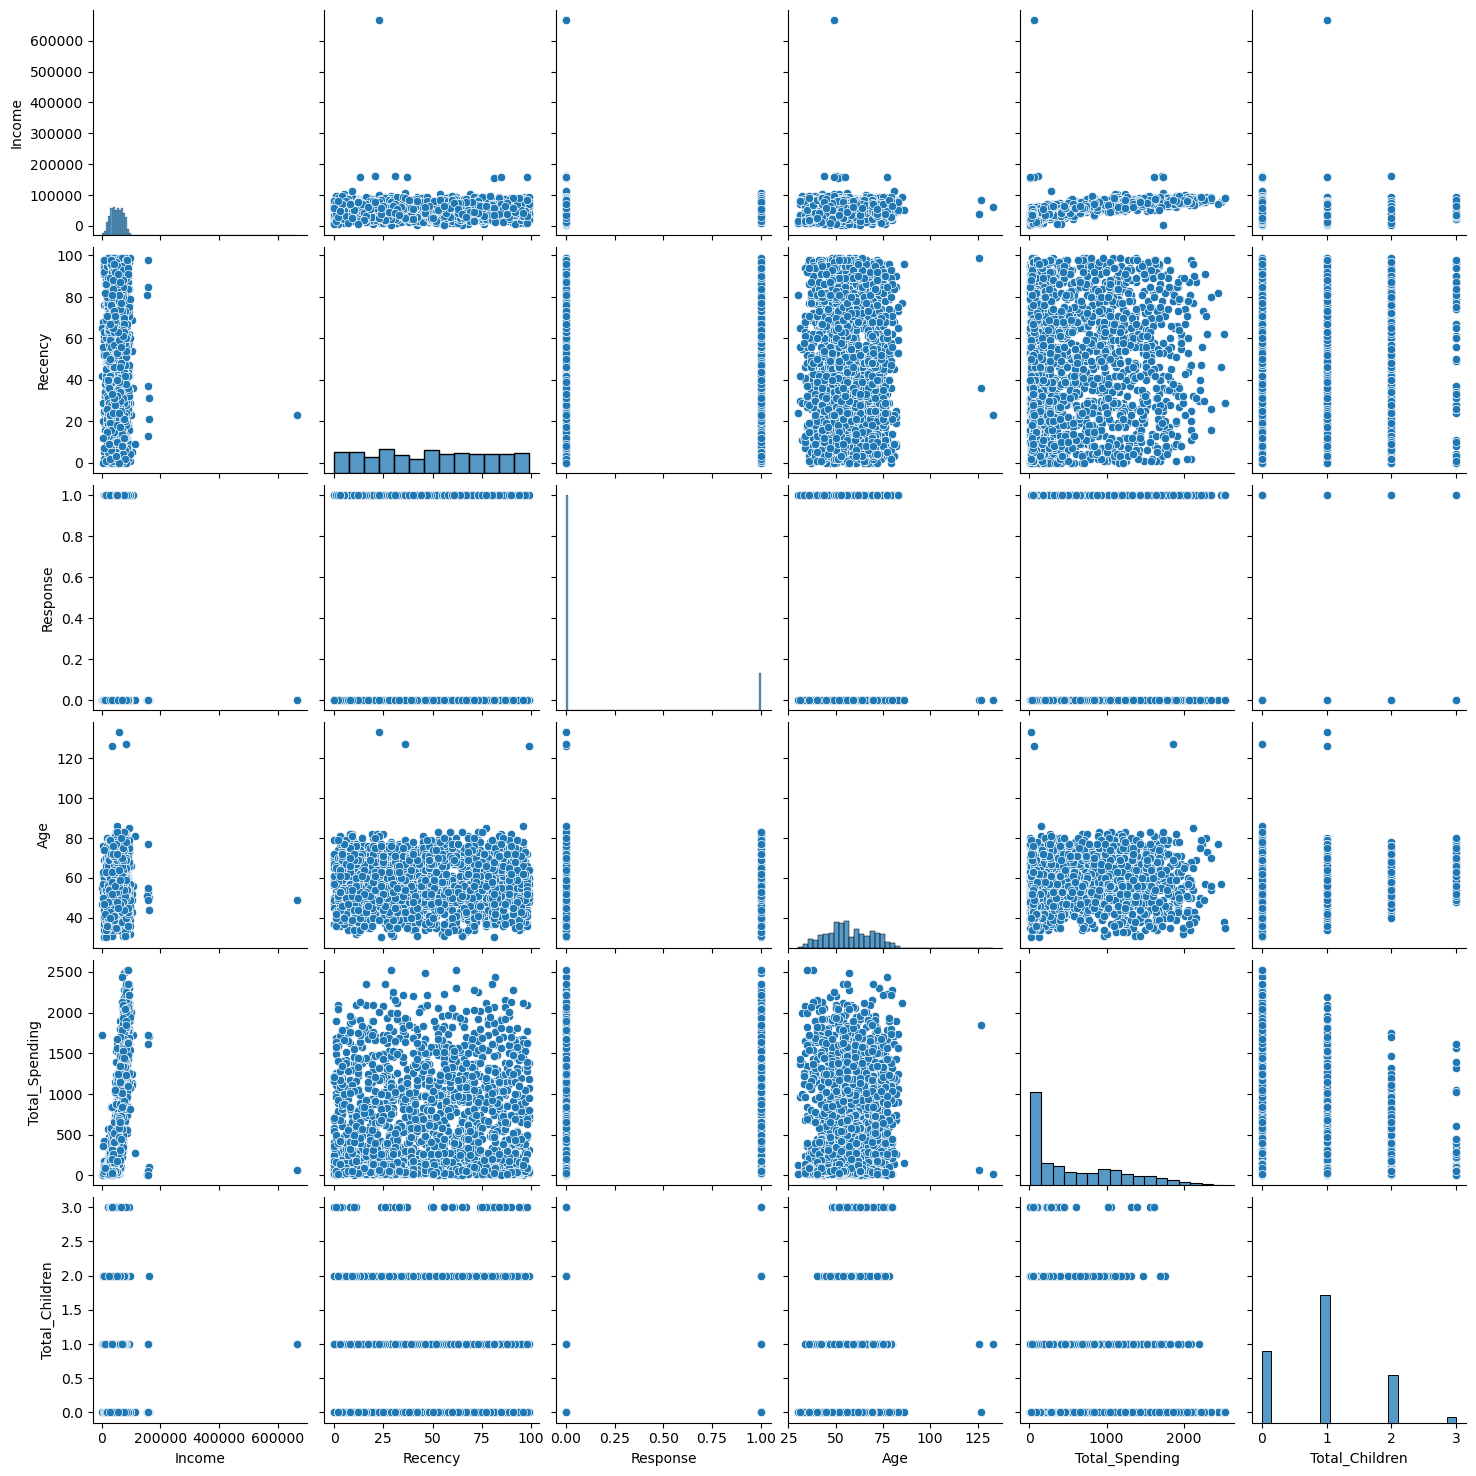

In [94]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])


# Remove Outliers

In [95]:
print("data size with outliersS: ",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
 
print("data size without outliers:",len(df_cleaned))

data size with outliersS:  2240
data size without outliers: 2237


In [96]:
len(df_cleaned)

2237

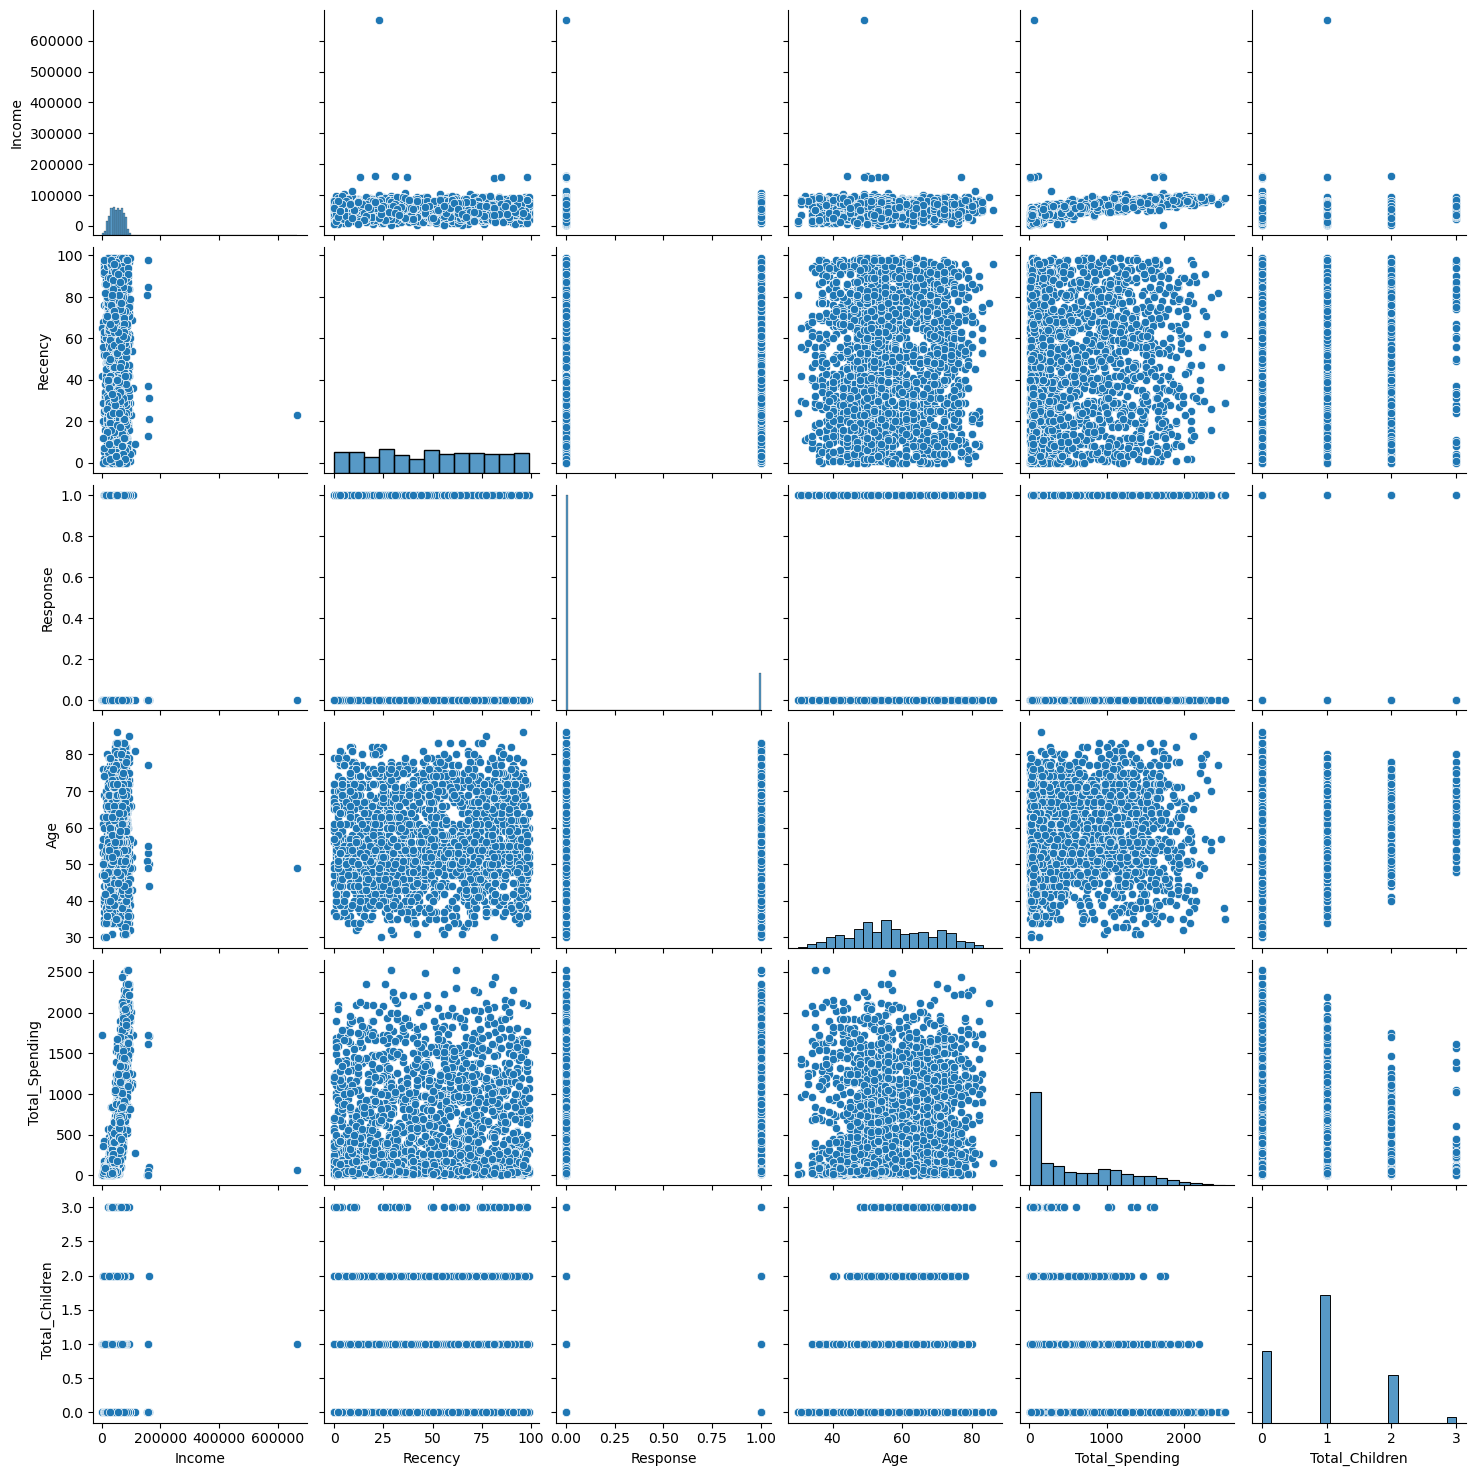

In [97]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

## Heat Map

<Axes: >

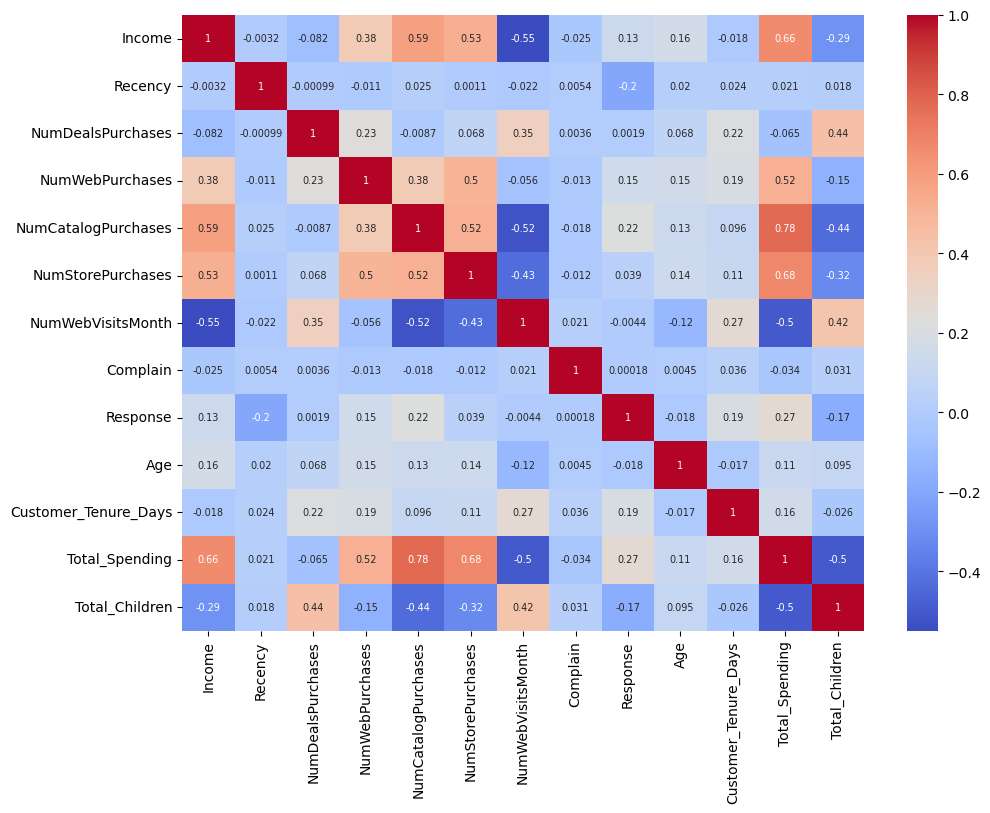

In [98]:
corr= df_cleaned.corr(numeric_only=True  )
plt.figure(figsize=(11,8))
sns.heatmap(
    corr,annot_kws={"size":7},
    annot=True,
    cmap="coolwarm"
)

In [99]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='str')

## Encoding


In [100]:
from sklearn.preprocessing import OneHotEncoder

In [101]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [102]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [103]:
enc_df.head(
    
)

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [104]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [105]:
df_encoded.shape

(2237, 18)

## Scaling

In [106]:
from sklearn.preprocessing import StandardScaler

In [107]:
X=df_encoded

In [108]:
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

In [109]:
X_scaled

array([[ 0.236068  ,  0.30727179,  0.34837058, ..., -0.35868917,
         1.3481025 , -1.3481025 ],
       [-0.23498225, -0.38358403, -0.16909621, ..., -0.35868917,
         1.3481025 , -1.3481025 ],
       [ 0.77425708, -0.79809753, -0.686563  , ..., -0.35868917,
        -0.74178336,  0.74178336],
       ...,
       [ 0.18985762,  1.44718391, -0.686563  , ..., -0.35868917,
         1.3481025 , -1.3481025 ],
       [ 0.67967959, -1.41986777, -0.16909621, ..., -0.35868917,
        -0.74178336,  0.74178336],
       [ 0.02562508, -0.31449845,  0.34837058, ..., -0.35868917,
        -0.74178336,  0.74178336]], shape=(2237, 18))

In [116]:
from sklearn.decomposition import PCA
pca = PCA(n_components= 3)
X_pca = pca.fit_transform(X_scaled)

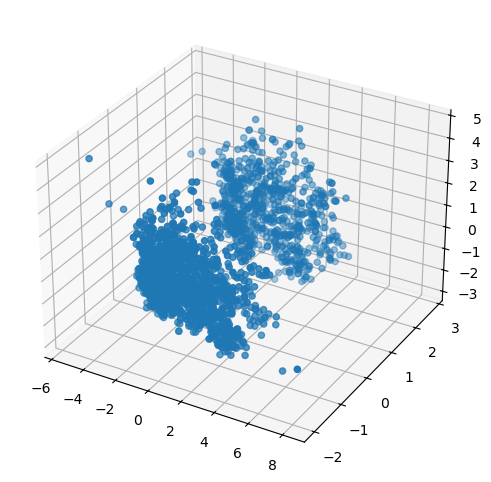

In [121]:
fig = plt.figure(figsize=(8,6))
ax= fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:, 0],X_pca[:, 1],X_pca[:, 2])

In [117]:
pca.explained_variance_ratio_

array([0.22170949, 0.11386416, 0.10404472])